In [1]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict


In [3]:
class State(TypedDict):
    marks: int
    result: str

In [4]:
def check_marks(state: State):
    print('checking marks...')

    return{}

In [7]:
def excellent_student(state: State):

    return{
        'result': 'Excellent student'
    }

In [8]:
def pass_student(state: State):

    return{
        'result': 'student passed'
    }

In [9]:
def fail_student(state: State):
    return{
        'result': 'fail student need more improvement'
    }

In [10]:
## Conditional routing function
def decide_result(state: State):
    if state['marks']>=80:
        return 'excellent_student'
    elif state['marks']>=50:
        return 'pass_student'
    else:
        return 'fail_student'

In [22]:
graph = StateGraph(State)

graph.add_node("check_marks", check_marks)
graph.add_node("excellent_student", excellent_student)
graph.add_node("pass_student", pass_student)
graph.add_node("fail_student", fail_student)

graph.add_edge(START, "check_marks")

graph.add_conditional_edges(
    "check_marks",
    decide_result,
    {
        "excellent_student": "excellent_student",
        "pass_student": "pass_student",
        "fail_student": "fail_student"
    }
)

graph.add_edge("excellent_student", END)
graph.add_edge("pass_student", END)
graph.add_edge("fail_student", END)

workflow = graph.compile()

In [23]:
result = workflow.invoke({
    'marks': 49
})

print(result)

checking marks...
{'marks': 49, 'result': 'fail student need more improvement'}


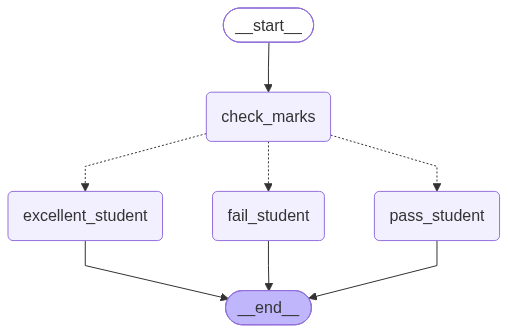

In [24]:
from IPython.display import Image, display

display(
    Image(
        workflow.get_graph().draw_mermaid_png()
    )
)